# Bias-Corrected Turnbull-Wakeman Demo

This notebook demonstrates four pricing methods for arithmetic Asian options:

1. **Plain Monte Carlo**
2. **Control Variate Monte Carlo**
3. **Turnbull-Wakeman approximation**
4. **Bias-corrected Turnbull-Wakeman approximation**

The bias correction model learns the scaled residual

$$
y = \frac{C_{\mathrm{TW}} - C_{\mathrm{CV}}}{S_0},
$$

and applies the correction

$$
C_{\mathrm{corrected}}
=
C_{\mathrm{TW}} - S_0 \widehat{y}.
$$


## 1. Imports and Project Setup

This notebook assumes it is located in the `notebooks/` folder of the project:

```text
AsianOption/
├── notebooks/
│   └── demo_bias_corrected_tw_with_plots.ipynb
├── data/
│   └── tw_residual_dataset_s0_grid.csv
├── arithmetic_asian_MC.py
├── control_variate.py
├── approximation.py
└── geometric_asian.py
```


In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display

from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import Ridge
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Project root
PROJECT_ROOT = Path.cwd()

# If this notebook is inside notebooks/, move one level up.
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

sys.path.append(str(PROJECT_ROOT))

DATA_DIR = PROJECT_ROOT / "data"
FIGURE_DIR = PROJECT_ROOT / "figures"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

from asianoption.arithmetic_asian_MC import arithmetic_asian_price_mc
from asianoption.control_variate import arithmetic_asian_cv
from asianoption.approximation import turnbull_wakeman_arithmetic_asian_price

print("Project root:", PROJECT_ROOT)
print("Data directory:", DATA_DIR)


Project root: /Users/bohanhou/PycharmProjects/AsianOption
Data directory: /Users/bohanhou/PycharmProjects/AsianOption/data


## 2. One-Case Pricing Example

We first price one arithmetic Asian call option using:

- Plain Monte Carlo
- Control variate Monte Carlo
- Turnbull-Wakeman approximation

The control variate Monte Carlo price is used as the benchmark in this project.


In [2]:
# One example case
S0 = 100
K = 100
r = 0.05
sigma = 0.20
T = 1.0
n = 12
n_paths = 100_000
seed = 42
option_type = "call"

plain_mc_price, plain_mc_se = arithmetic_asian_price_mc(
    S0=S0,
    K=K,
    r=r,
    sigma=sigma,
    T=T,
    n=n,
    n_paths=n_paths,
    seed=seed,
    option_type=option_type,
)

cv_result = arithmetic_asian_cv(
    S0=S0,
    K=K,
    r=r,
    sigma=sigma,
    T=T,
    n=n,
    n_paths=n_paths,
    seed=seed,
    option_type=option_type,
)

tw_price = turnbull_wakeman_arithmetic_asian_price(
    S0=S0,
    K=K,
    r=r,
    sigma=sigma,
    T=T,
    n=n,
    option_type=option_type,
)

one_case = pd.DataFrame([
    {
        "Method": "Plain Monte Carlo",
        "Price": plain_mc_price,
        "Std Error": plain_mc_se,
        "Error vs CV": plain_mc_price - cv_result.price,
    },
    {
        "Method": "Control Variate Monte Carlo",
        "Price": cv_result.price,
        "Std Error": cv_result.std_error,
        "Error vs CV": 0.0,
    },
    {
        "Method": "Turnbull-Wakeman",
        "Price": tw_price,
        "Std Error": np.nan,
        "Error vs CV": tw_price - cv_result.price,
    },
])

one_case


,Method,Price,Std Error,Error vs CV
0,Plain Monte Carlo,6.158862,0.026962,0.001720
1,Control Variate Monte Carlo,6.157143,0.000757,0.000000
2,Turnbull-Wakeman,6.174171,NaN,0.017028


## 3. Load Residual Dataset

The residual dataset was generated on a parameter grid. Each row contains:

```text
S0, K, moneyness, sigma, T, n,
CV Monte Carlo price,
Turnbull-Wakeman price,
TW residual
```

The target for the bias model is the scaled residual:

```text
scaled_tw_residual = (TW price - CV price) / S0
```


In [3]:
DATA_PATH = DATA_DIR / "tw_residual_dataset_s0_grid.csv"

df = pd.read_csv(DATA_PATH)

# Recompute features to make the notebook self-contained.
df["moneyness"] = df["K"] / df["S0"]
df["log_moneyness"] = np.log(df["moneyness"])
df["inv_n"] = 1.0 / df["n"]

df["tw_residual"] = df["tw_price"] - df["cv_mc_price"]
df["tw_abs_residual"] = np.abs(df["tw_residual"])
df["scaled_tw_residual"] = df["tw_residual"] / df["S0"]

print("Dataset shape:", df.shape)
df.head()


Dataset shape: (3360, 20)


,S0,K,moneyness,log_moneyness,r,T,sigma,sigma2,n,inv_n,inv_sqrt_n,option_type,cv_mc_price,cv_mc_se,tw_price,tw_residual,tw_abs_residual,tw_rel_residual,scaled_tw_residual,scaled_tw_abs_residual
0,80,56.0,0.7,-0.356675,0.05,0.25,0.1,0.01,12,0.083333,0.288675,call,24.239129,0.000034,24.239135,0.000005,0.000005,2.171839e-07,6.580435e-08,6.580435e-08
1,80,56.0,0.7,-0.356675,0.05,0.25,0.1,0.01,26,0.038462,0.196116,call,24.216808,0.000034,24.216833,0.000024,0.000024,1.007011e-06,3.048325e-07,3.048325e-07
2,80,56.0,0.7,-0.356675,0.05,0.25,0.1,0.01,52,0.019231,0.138675,call,24.207304,0.000034,24.207276,-0.000028,0.000028,-1.168068e-06,-3.534471e-07,3.534471e-07
3,80,56.0,0.7,-0.356675,0.05,0.25,0.1,0.01,126,0.007937,0.089087,call,24.201654,0.000034,24.201664,0.000009,0.000009,3.831632e-07,1.159148e-07,1.159148e-07
4,80,56.0,0.7,-0.356675,0.05,0.25,0.2,0.04,12,0.083333,0.288675,call,24.238933,0.000135,24.239135,0.000201,0.000201,8.301828e-06,2.515343e-06,2.515343e-06


## 4. Train Bias-Correction Model

We fit a cubic polynomial Ridge regression model.

The feature set is exactly:

```text
features = [log_moneyness, sigma, T, inv_n]
```

where:

```text
inv_n = 1 / n
```

No `1 / sqrt(n)` feature is used in this demo.

The target is:

```text
target = scaled_tw_residual = (TW price - CV benchmark price) / S0
```

This model learns the systematic Turnbull-Wakeman residual relative to the control variate benchmark.


In [4]:
FEATURES = [
    "log_moneyness",
    "sigma",
    "T",
    "inv_n",
]

X = df[FEATURES]
y = df["scaled_tw_residual"]

X_train, X_test, y_train, y_test, df_train, df_test = train_test_split(
    X,
    y,
    df,
    test_size=0.25,
    random_state=42,
    shuffle=True,
)

bias_model = make_pipeline(
    PolynomialFeatures(degree=3, include_bias=False),
    StandardScaler(),
    Ridge(alpha=1.0),
)

bias_model.fit(X_train, y_train)

pred_train = bias_model.predict(X_train)
pred_test = bias_model.predict(X_test)

def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

print("Train MAE scaled :", mean_absolute_error(y_train, pred_train))
print("Test MAE scaled  :", mean_absolute_error(y_test, pred_test))
print("Train RMSE scaled:", rmse(y_train, pred_train))
print("Test RMSE scaled :", rmse(y_test, pred_test))
print("Test R2          :", r2_score(y_test, pred_test))


Train MAE scaled : 0.00012057969078310532
Test MAE scaled  : 0.00012384986559714497
Train RMSE scaled: 0.00015835708228261028
Test RMSE scaled : 0.00016376970123572538
Test R2          : 0.9912172130432875


## 5. Apply Bias Correction

The model predicts the scaled TW bias:

```text
predicted_scaled_bias ≈ (TW price - CV price) / S0
```

Then the corrected price is

```text
corrected TW price = TW price - S0 * predicted_scaled_bias
```


In [5]:
df_test = df_test.copy()

df_test["predicted_scaled_tw_bias"] = pred_test
df_test["predicted_tw_bias"] = df_test["S0"] * df_test["predicted_scaled_tw_bias"]

df_test["tw_corrected_price"] = df_test["tw_price"] - df_test["predicted_tw_bias"]
df_test["tw_corrected_error"] = df_test["tw_corrected_price"] - df_test["cv_mc_price"]
df_test["tw_corrected_abs_error"] = np.abs(df_test["tw_corrected_error"])

original_mae = df_test["tw_abs_residual"].mean()
corrected_mae = df_test["tw_corrected_abs_error"].mean()

original_rmse = rmse(df_test["tw_residual"], np.zeros(len(df_test)))
corrected_rmse = rmse(df_test["tw_corrected_error"], np.zeros(len(df_test)))

original_max = df_test["tw_abs_residual"].max()
corrected_max = df_test["tw_corrected_abs_error"].max()

improved_fraction = (
    df_test["tw_corrected_abs_error"] < df_test["tw_abs_residual"]
).mean()

summary = pd.DataFrame([
    {
        "Metric": "MAE",
        "Original TW": original_mae,
        "Corrected TW": corrected_mae,
        "Reduction": 1 - corrected_mae / original_mae,
    },
    {
        "Metric": "RMSE",
        "Original TW": original_rmse,
        "Corrected TW": corrected_rmse,
        "Reduction": 1 - corrected_rmse / original_rmse,
    },
    {
        "Metric": "Max Abs Error",
        "Original TW": original_max,
        "Corrected TW": corrected_max,
        "Reduction": 1 - corrected_max / original_max,
    },
])

print(f"Improved cases: {100 * improved_fraction:.2f}%")
summary


Improved cases: 66.90%


,Metric,Original TW,Corrected TW,Reduction
0,MAE,0.091455,0.012304,0.865467
1,RMSE,0.192261,0.016459,0.914394
2,Max Abs Error,1.078233,0.078131,0.927538


## 6. Single-Case Correction Example

The aggregate method improves MAE, but not every individual case necessarily improves.
For a clear demonstration, this section automatically selects the test case where the correction reduces absolute error the most.

The same feature set is used:

```text
[log_moneyness, sigma, T, inv_n]
```


In [12]:
# Pick the test case where the bias correction improves the TW error the most.

df_demo = df_test.copy()
df_demo["improvement"] = df_demo["tw_abs_residual"] - df_demo["tw_corrected_abs_error"]

case = df_demo.loc[df_demo["improvement"].idxmax()]

S0_case = case["S0"]
K_case = case["K"]
sigma_case = case["sigma"]
T_case = case["T"]
n_case = int(case["n"])

cv_benchmark = case["cv_mc_price"]
tw_case_price = case["tw_price"]

x_new = pd.DataFrame(
    {
        "log_moneyness": [np.log(K_case / S0_case)],
        "sigma": [sigma_case],
        "T": [T_case],
        "inv_n": [1.0 / n_case],
    }
)

predicted_scaled_residual = bias_model.predict(x_new)[0]
predicted_residual = S0_case * predicted_scaled_residual

corrected_price = tw_case_price - predicted_residual

original_error = tw_case_price - cv_benchmark
corrected_error = corrected_price - cv_benchmark

single_case_results = pd.DataFrame(
    {
        "Quantity": [
            "S0",
            "K",
            "Moneyness K/S0",
            "sigma",
            "T",
            "n",
            "CV Benchmark",
            "Original TW Price",
            "Predicted Residual",
            "Corrected TW Price",
            "Original TW Error",
            "Corrected TW Error",
            "Original Absolute Error",
            "Corrected Absolute Error",
            "Absolute Error Reduction",
        ],
        "Value": [
            S0_case,
            K_case,
            K_case / S0_case,
            sigma_case,
            T_case,
            n_case,
            cv_benchmark,
            tw_case_price,
            predicted_residual,
            corrected_price,
            original_error,
            corrected_error,
            abs(original_error),
            abs(corrected_error),
            abs(original_error) - abs(corrected_error),
        ],
    }
)

single_case_results


,Quantity,Value
0,S0,120.000000
1,K,96.000000
2,Moneyness K/S0,0.800000
3,sigma,0.600000
4,T,2.000000
5,n,126.000000
6,CV Benchmark,35.744521
7,Original TW Price,36.822754
8,Predicted Residual,1.045901
9,Corrected TW Price,35.776853


## 7. Plot: Original vs Corrected Error

Each point is one test case.

- x-axis: original Turnbull-Wakeman error
- y-axis: corrected Turnbull-Wakeman error

A successful correction should move points closer to the horizontal zero-error line.


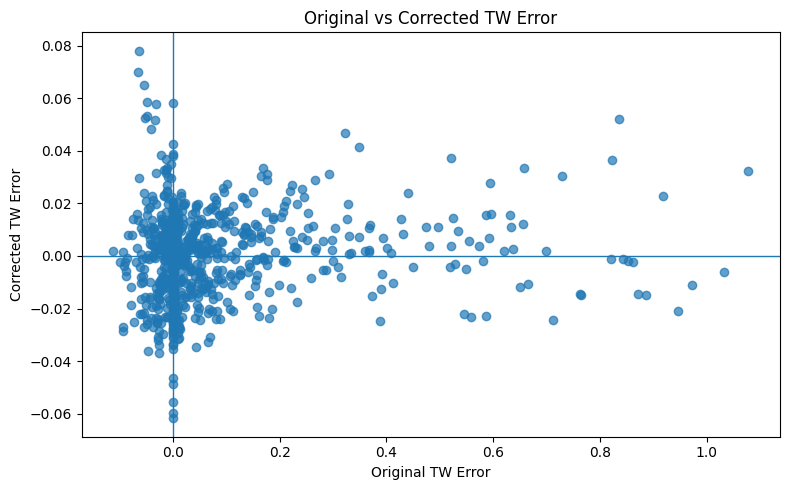

Saved figure to: /Users/bohanhou/PycharmProjects/AsianOption/figures/demo_original_vs_corrected_tw_error.png


In [13]:
plt.figure(figsize=(8, 5))

plt.scatter(
    df_test["tw_residual"],
    df_test["tw_corrected_error"],
    alpha=0.7,
)

plt.axhline(0.0, linewidth=1)
plt.axvline(0.0, linewidth=1)

plt.xlabel("Original TW Error")
plt.ylabel("Corrected TW Error")
plt.title("Original vs Corrected TW Error")
plt.tight_layout()

save_path = FIGURE_DIR / "demo_original_vs_corrected_tw_error.png"
plt.savefig(save_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved figure to:", save_path)


## 8. Plot: MAE Before and After Correction

This bar chart compares the mean absolute error of the original Turnbull-Wakeman approximation and the bias-corrected Turnbull-Wakeman approximation.


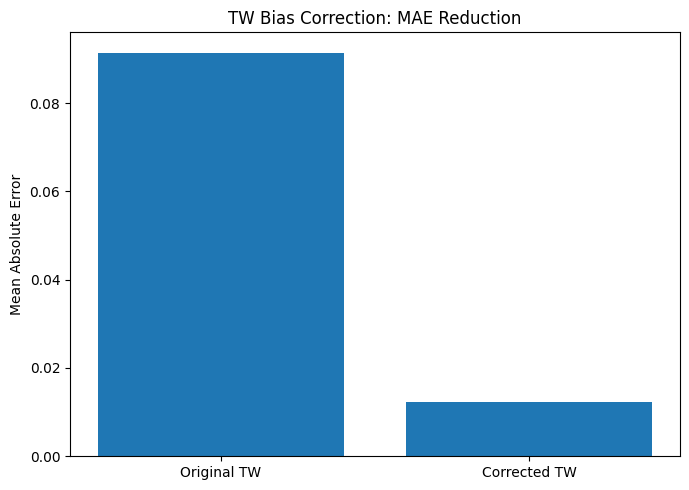

Saved figure to: /Users/bohanhou/PycharmProjects/AsianOption/figures/demo_tw_vs_corrected_mae.png


In [14]:
labels = ["Original TW", "Corrected TW"]
values = [
    df_test["tw_abs_residual"].mean(),
    df_test["tw_corrected_abs_error"].mean(),
]

plt.figure(figsize=(7, 5))
plt.bar(labels, values)

plt.ylabel("Mean Absolute Error")
plt.title("TW Bias Correction: MAE Reduction")
plt.tight_layout()

save_path = FIGURE_DIR / "demo_tw_vs_corrected_mae.png"
plt.savefig(save_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved figure to:", save_path)


## 9. Plot: Error vs Strike for a Fixed Regime

This plot shows original and corrected TW errors across strikes for a selected volatility, maturity, monitoring frequency, and spot level.


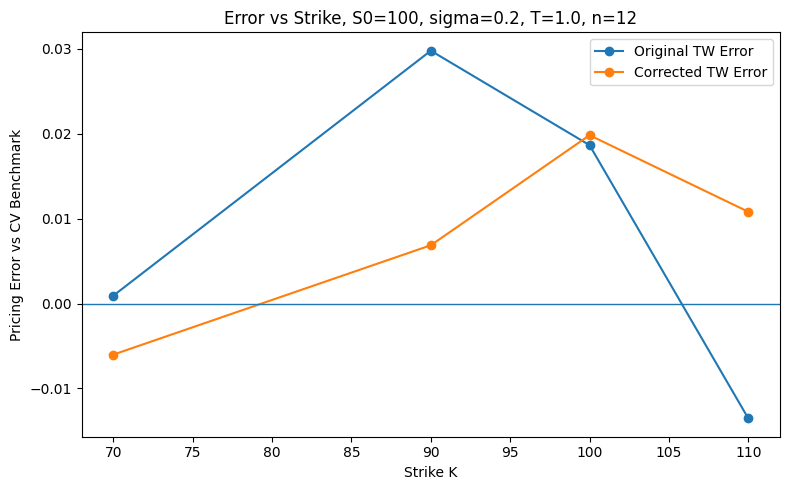

Saved figure to: /Users/bohanhou/PycharmProjects/AsianOption/figures/demo_error_vs_strike.png


In [9]:
def plot_error_vs_strike(
    df_result,
    S0_fixed=100,
    sigma_fixed=0.2,
    T_fixed=1.0,
    n_fixed=12,
):
    sub = df_result[
        (df_result["S0"] == S0_fixed)
        & (df_result["sigma"] == sigma_fixed)
        & (df_result["T"] == T_fixed)
        & (df_result["n"] == n_fixed)
    ].copy()

    if sub.empty:
        print("No matching data for selected regime.")
        return

    sub = sub.sort_values("K")

    plt.figure(figsize=(8, 5))
    plt.plot(sub["K"], sub["tw_residual"], marker="o", label="Original TW Error")
    plt.plot(sub["K"], sub["tw_corrected_error"], marker="o", label="Corrected TW Error")
    plt.axhline(0.0, linewidth=1)

    plt.xlabel("Strike K")
    plt.ylabel("Pricing Error vs CV Benchmark")
    plt.title(
        f"Error vs Strike, S0={S0_fixed}, sigma={sigma_fixed}, "
        f"T={T_fixed}, n={n_fixed}"
    )
    plt.legend()
    plt.tight_layout()

    save_path = FIGURE_DIR / "demo_error_vs_strike.png"
    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()

    print("Saved figure to:", save_path)


plot_error_vs_strike(
    df_test,
    S0_fixed=100,
    sigma_fixed=0.2,
    T_fixed=1.0,
    n_fixed=12,
)


## 10. Display Saved Project Figures

This section displays project-level figures if they already exist in the `figures/` directory.



Approximation Error vs Strike


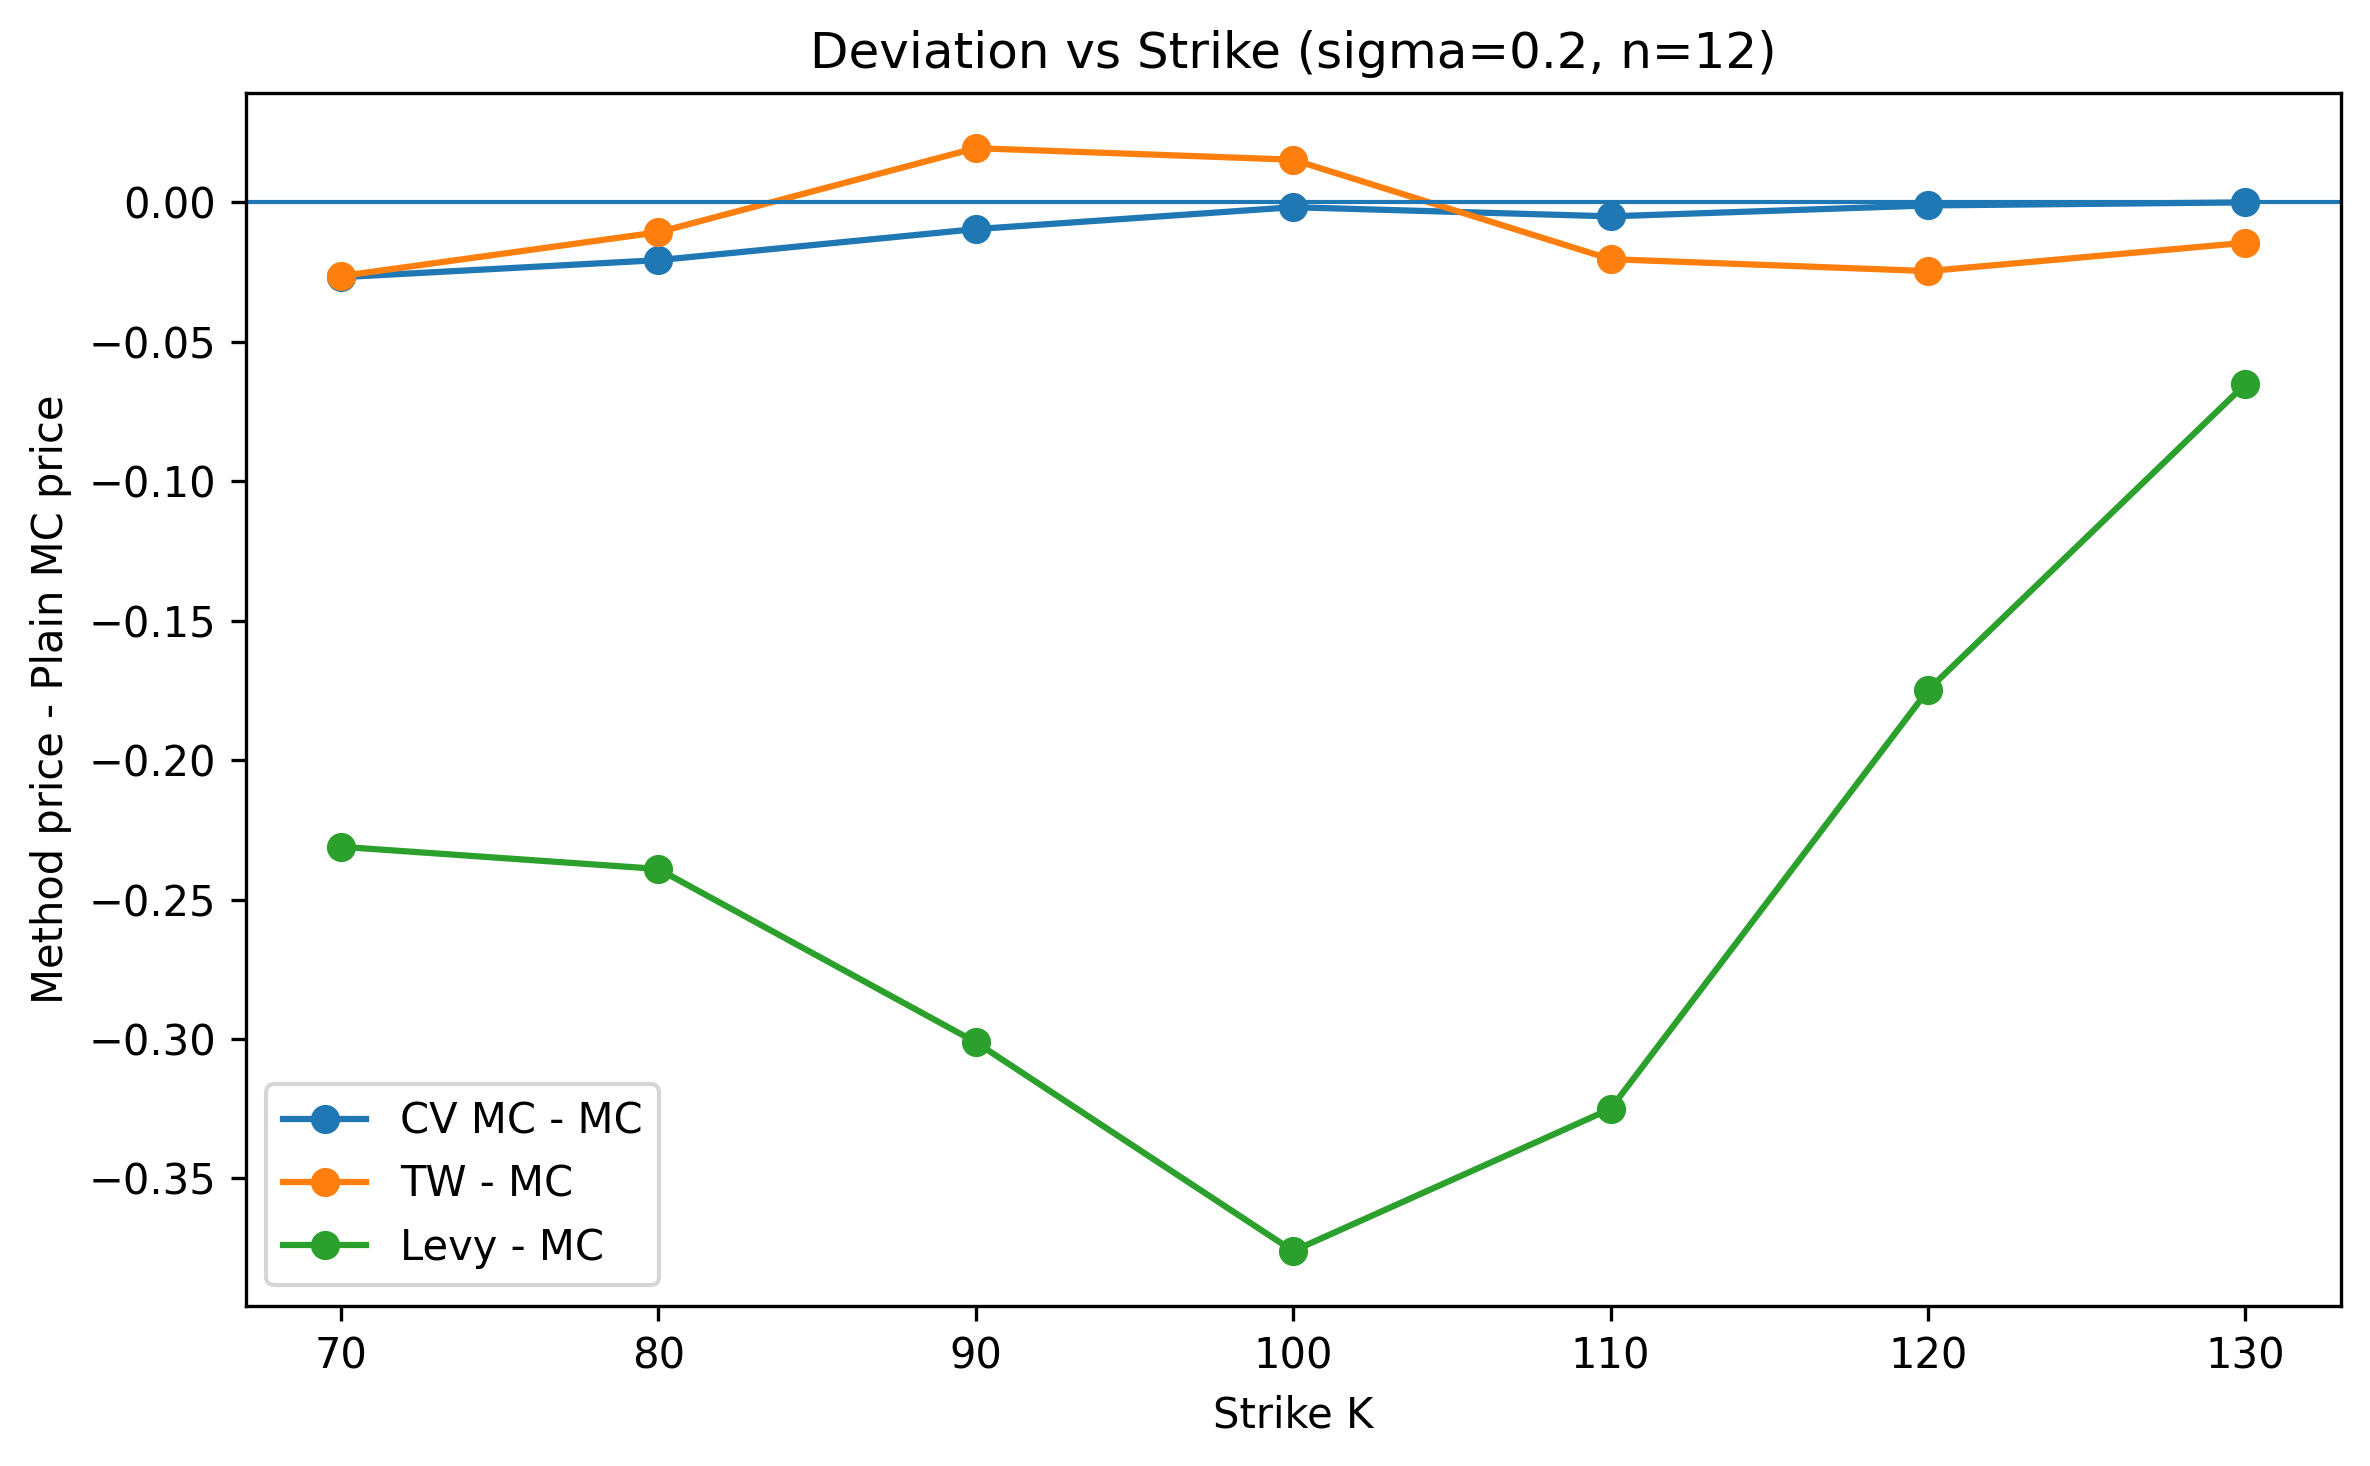


Approximation Error vs Volatility


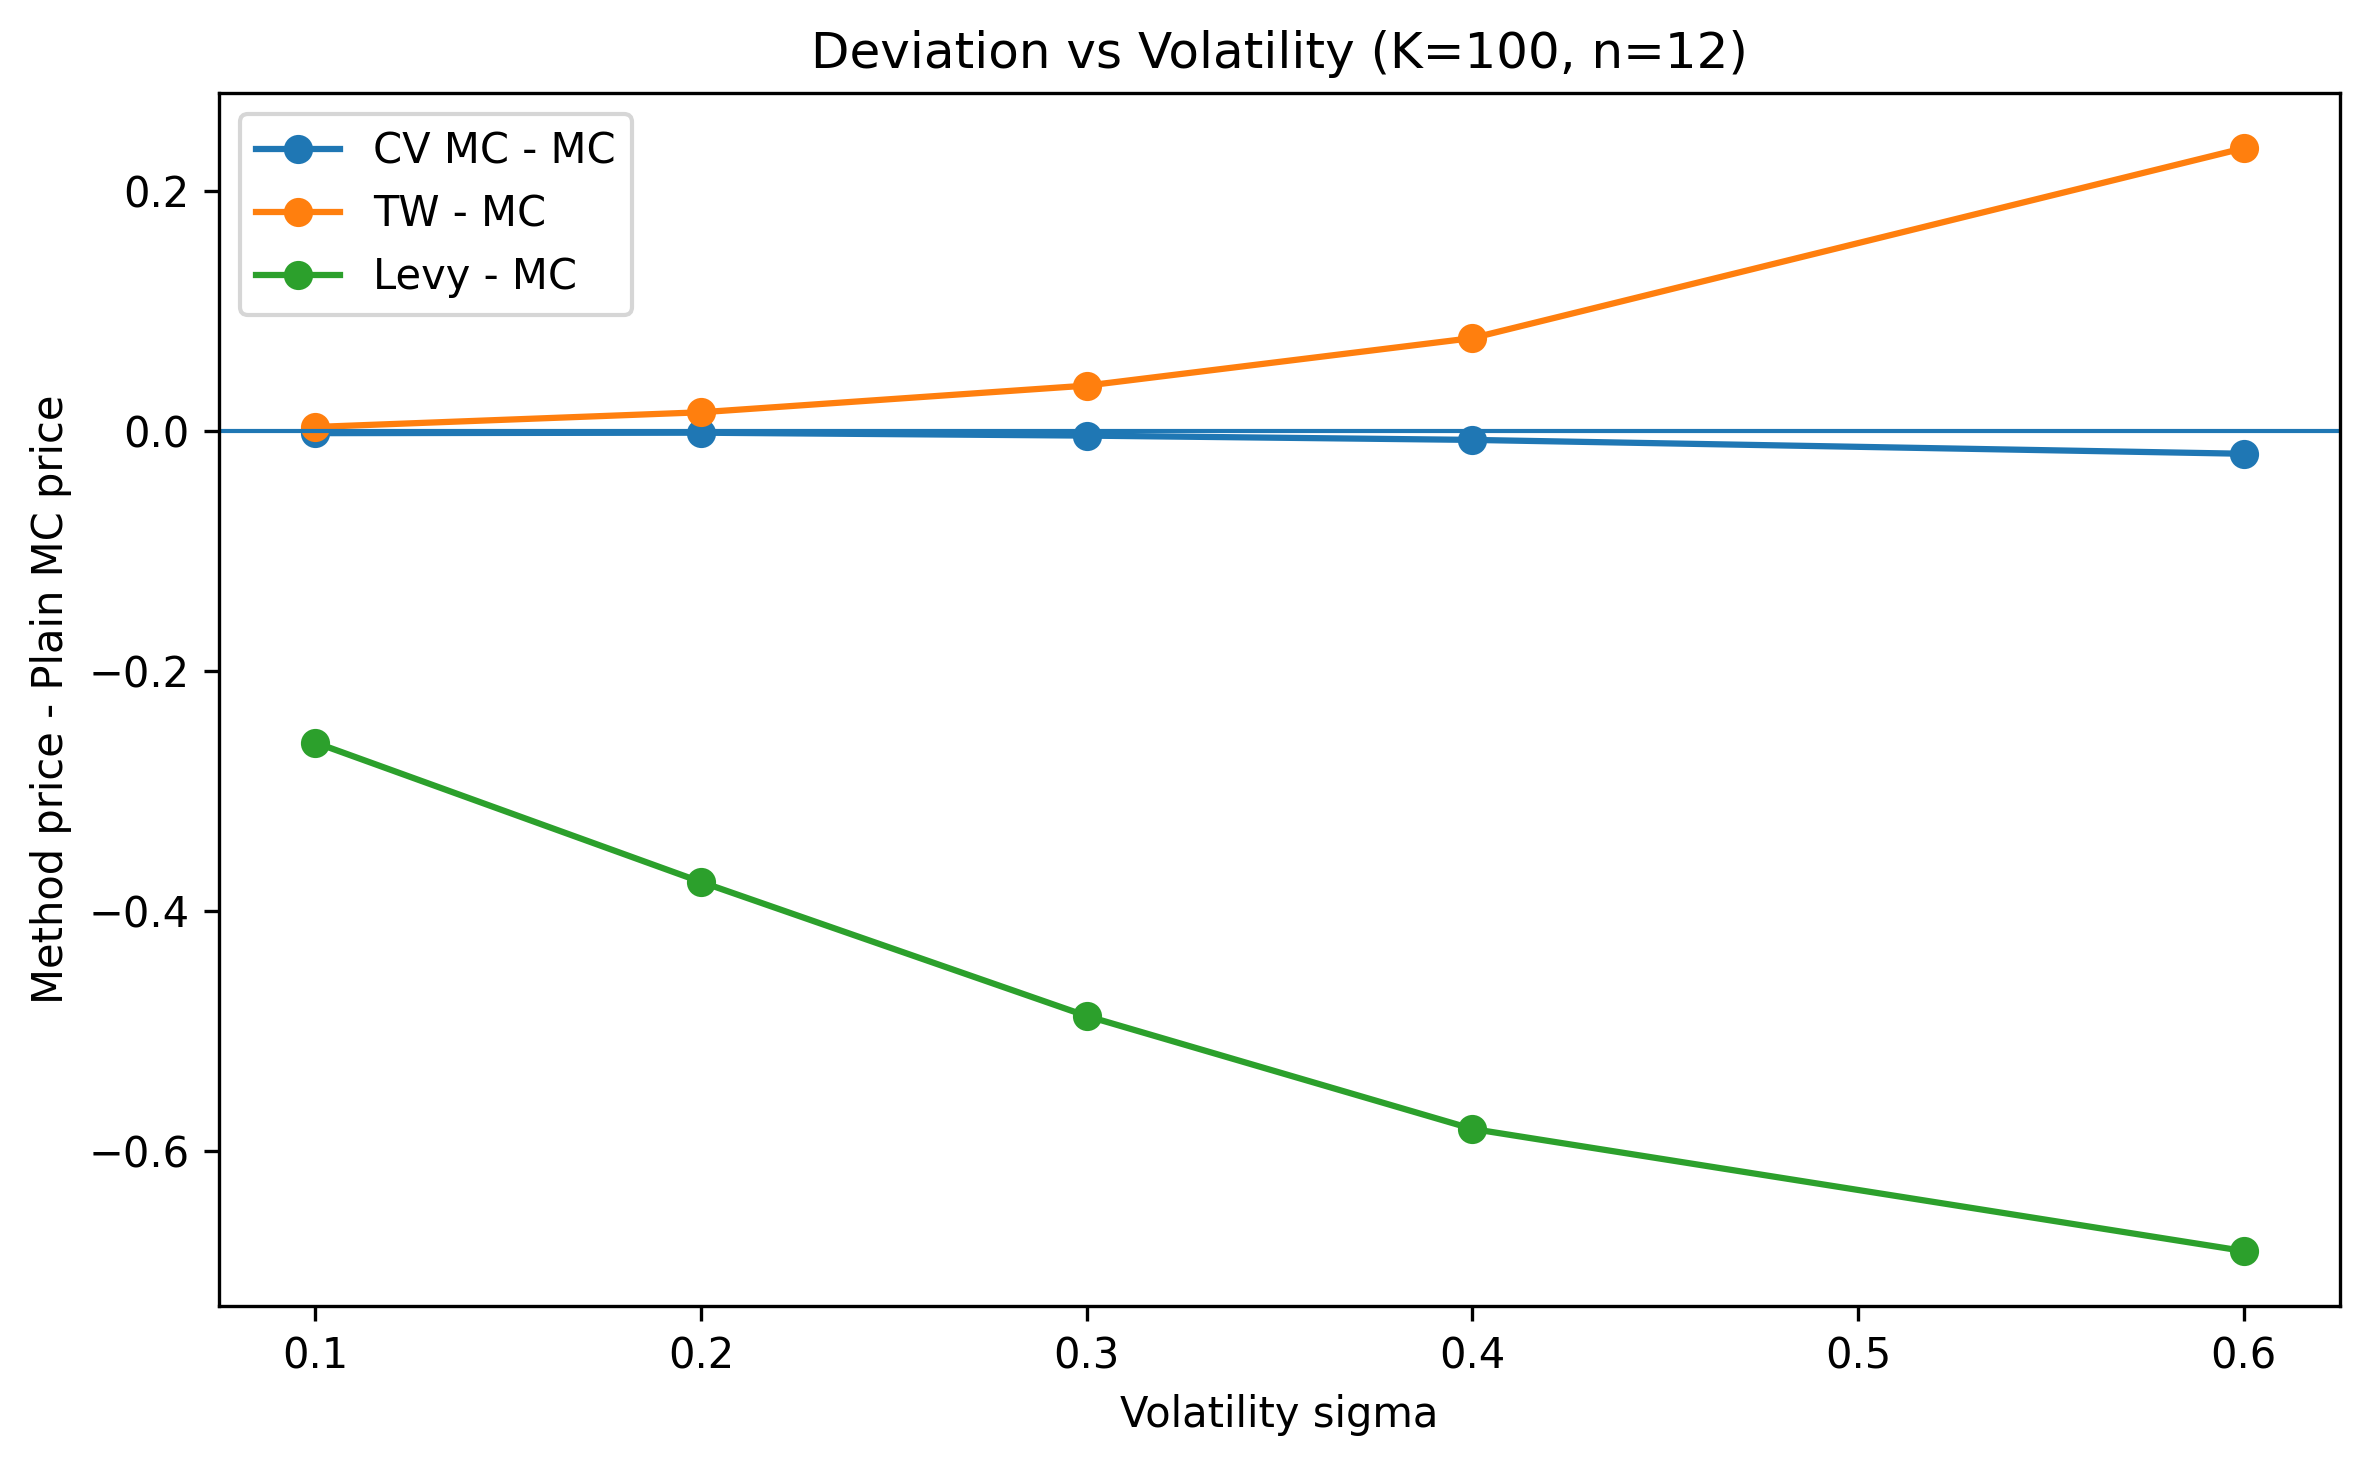


Runtime vs Monitoring Frequency


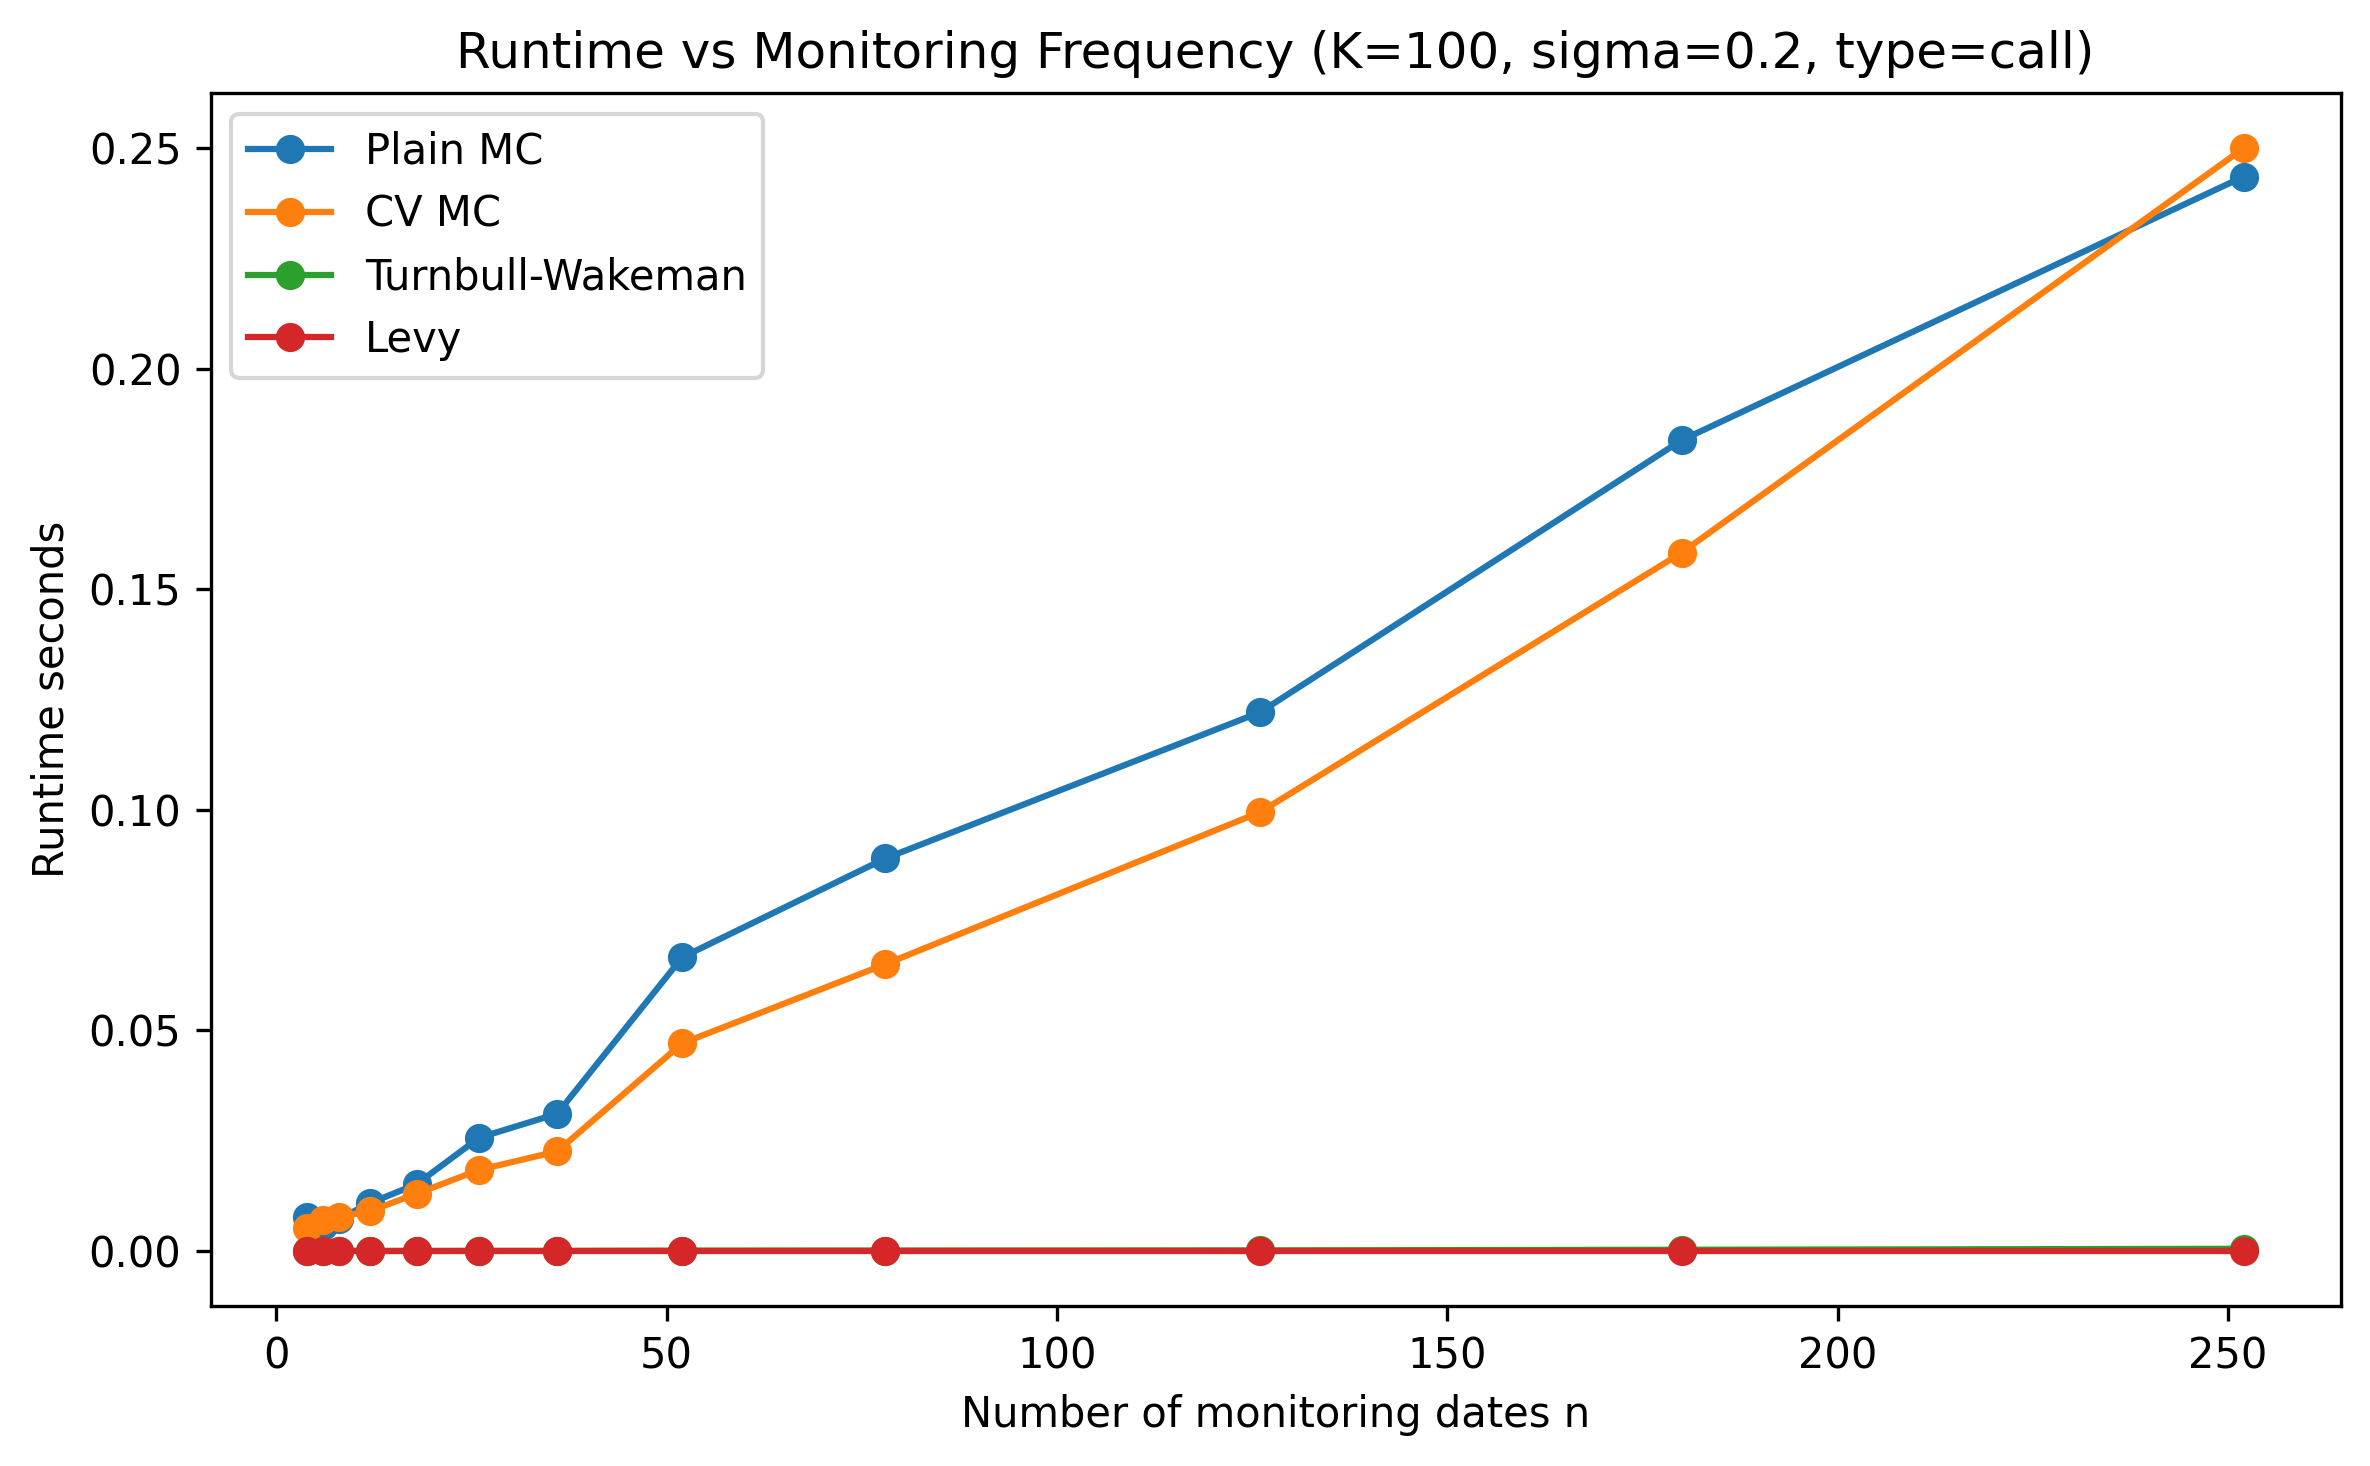


Random Test Set: Original vs Corrected TW Error


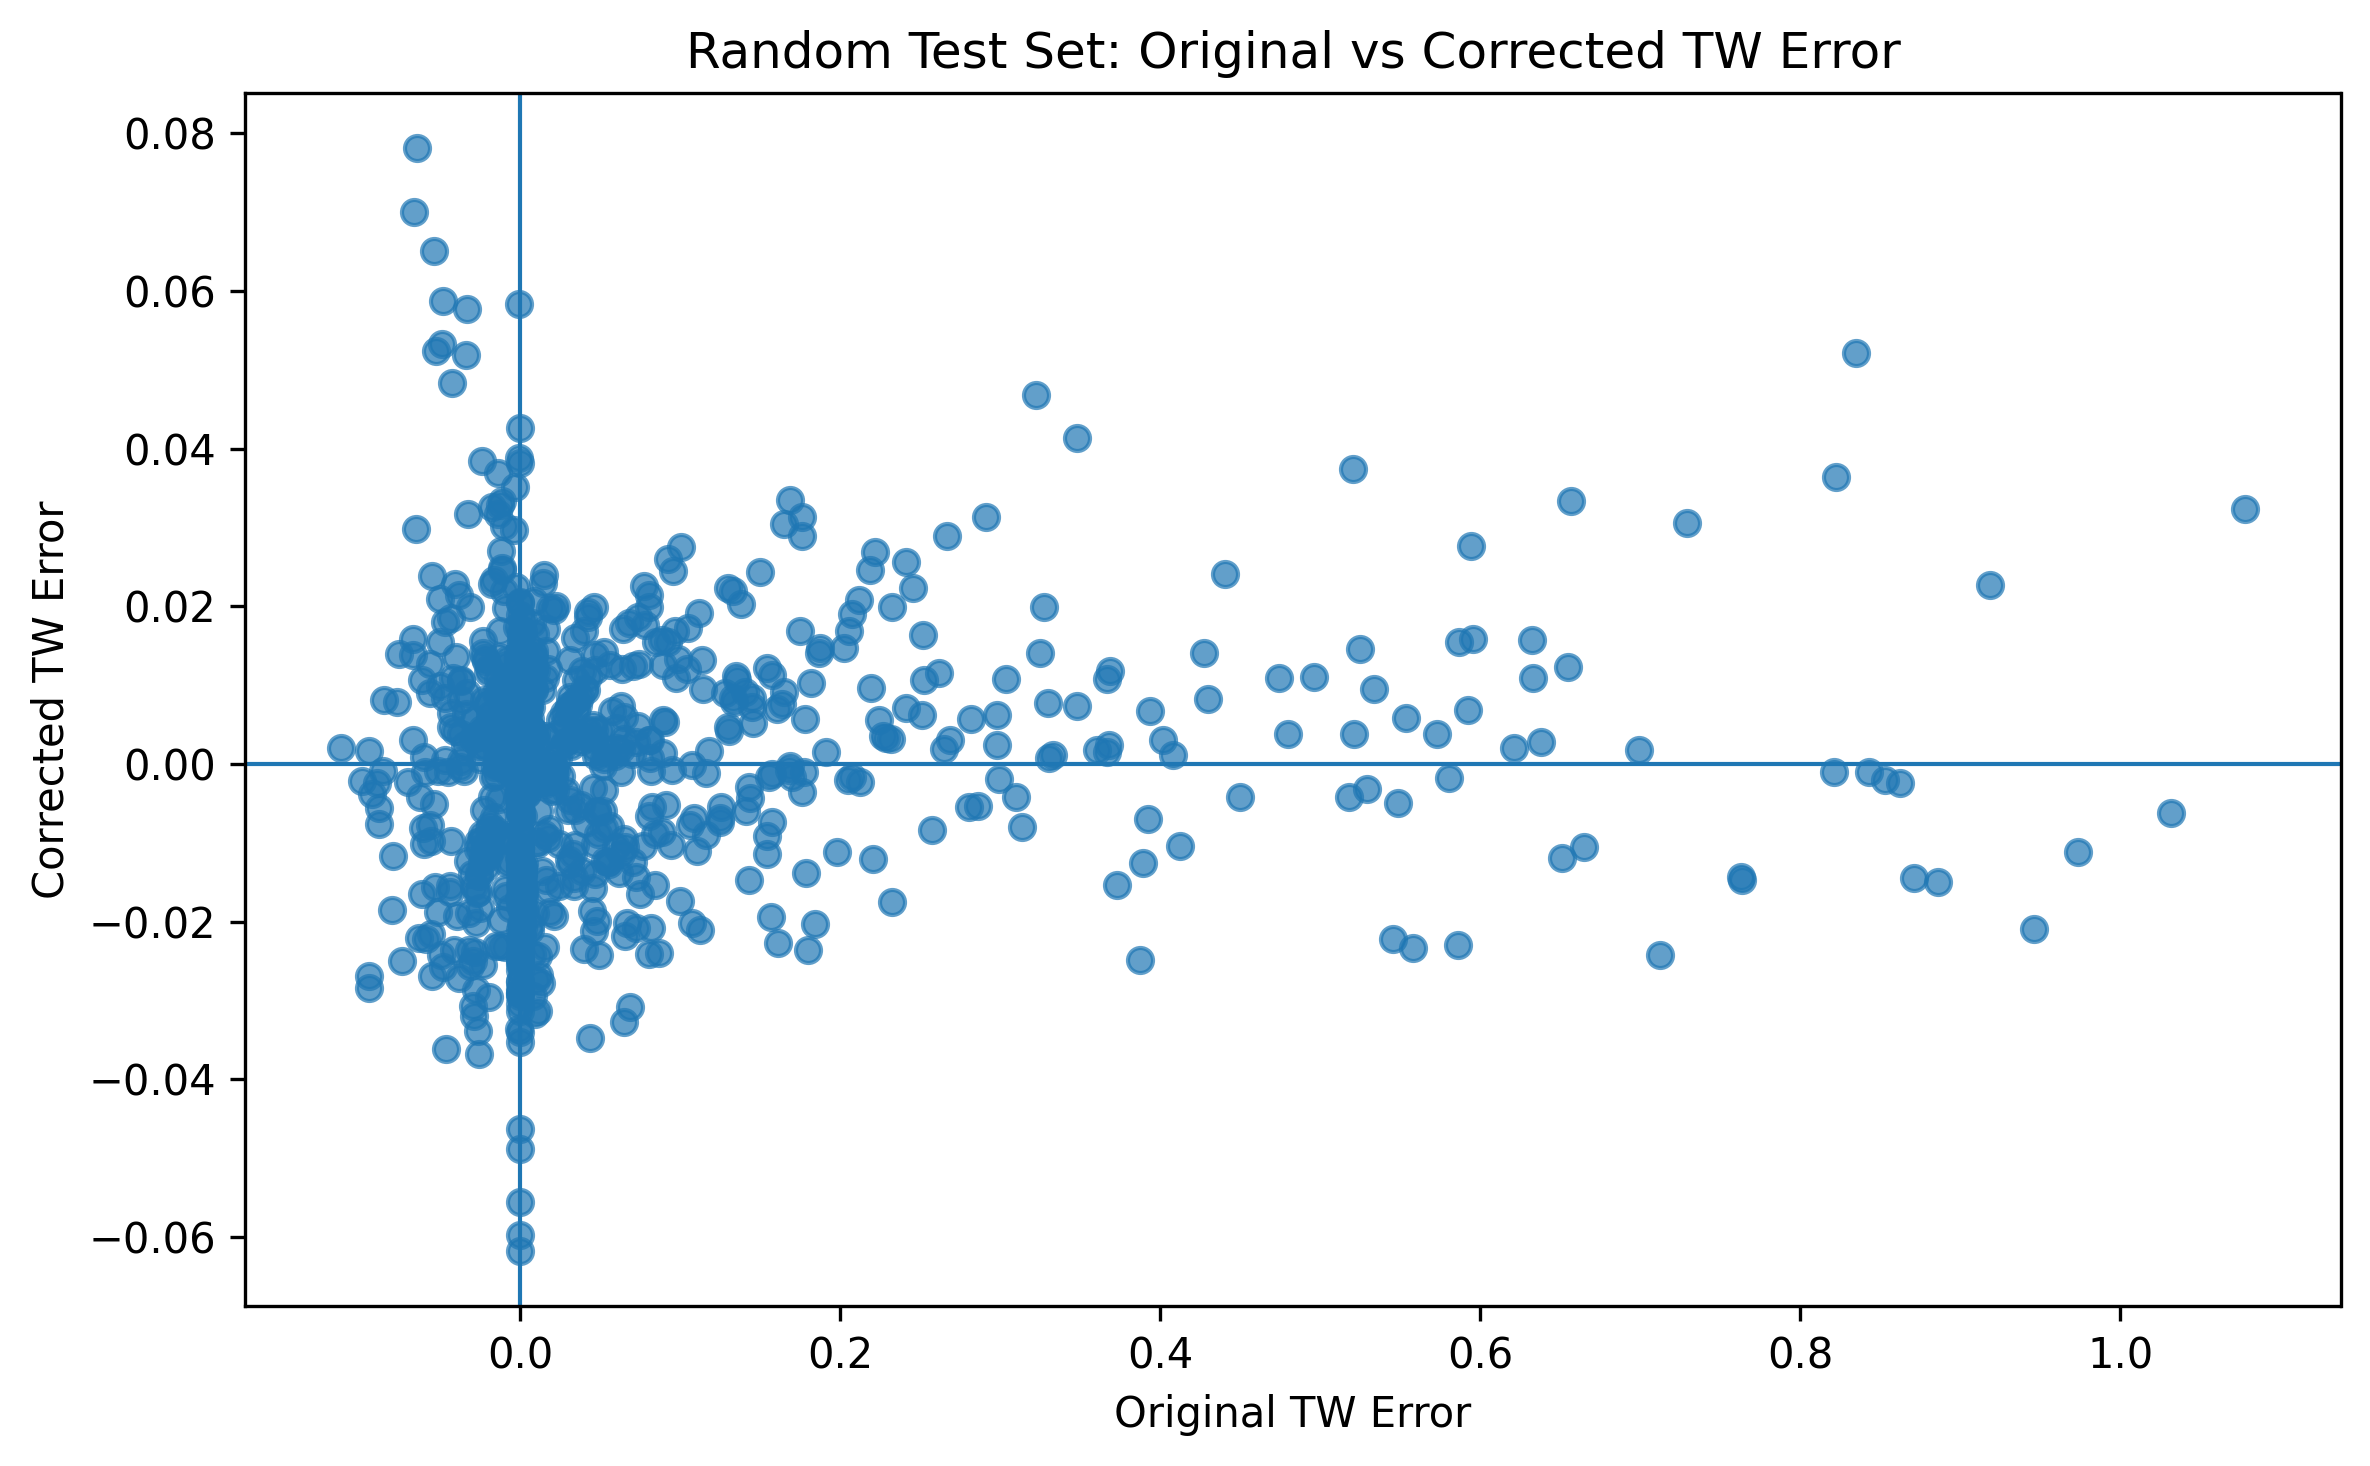


Random Test Set: TW vs Corrected TW MAE


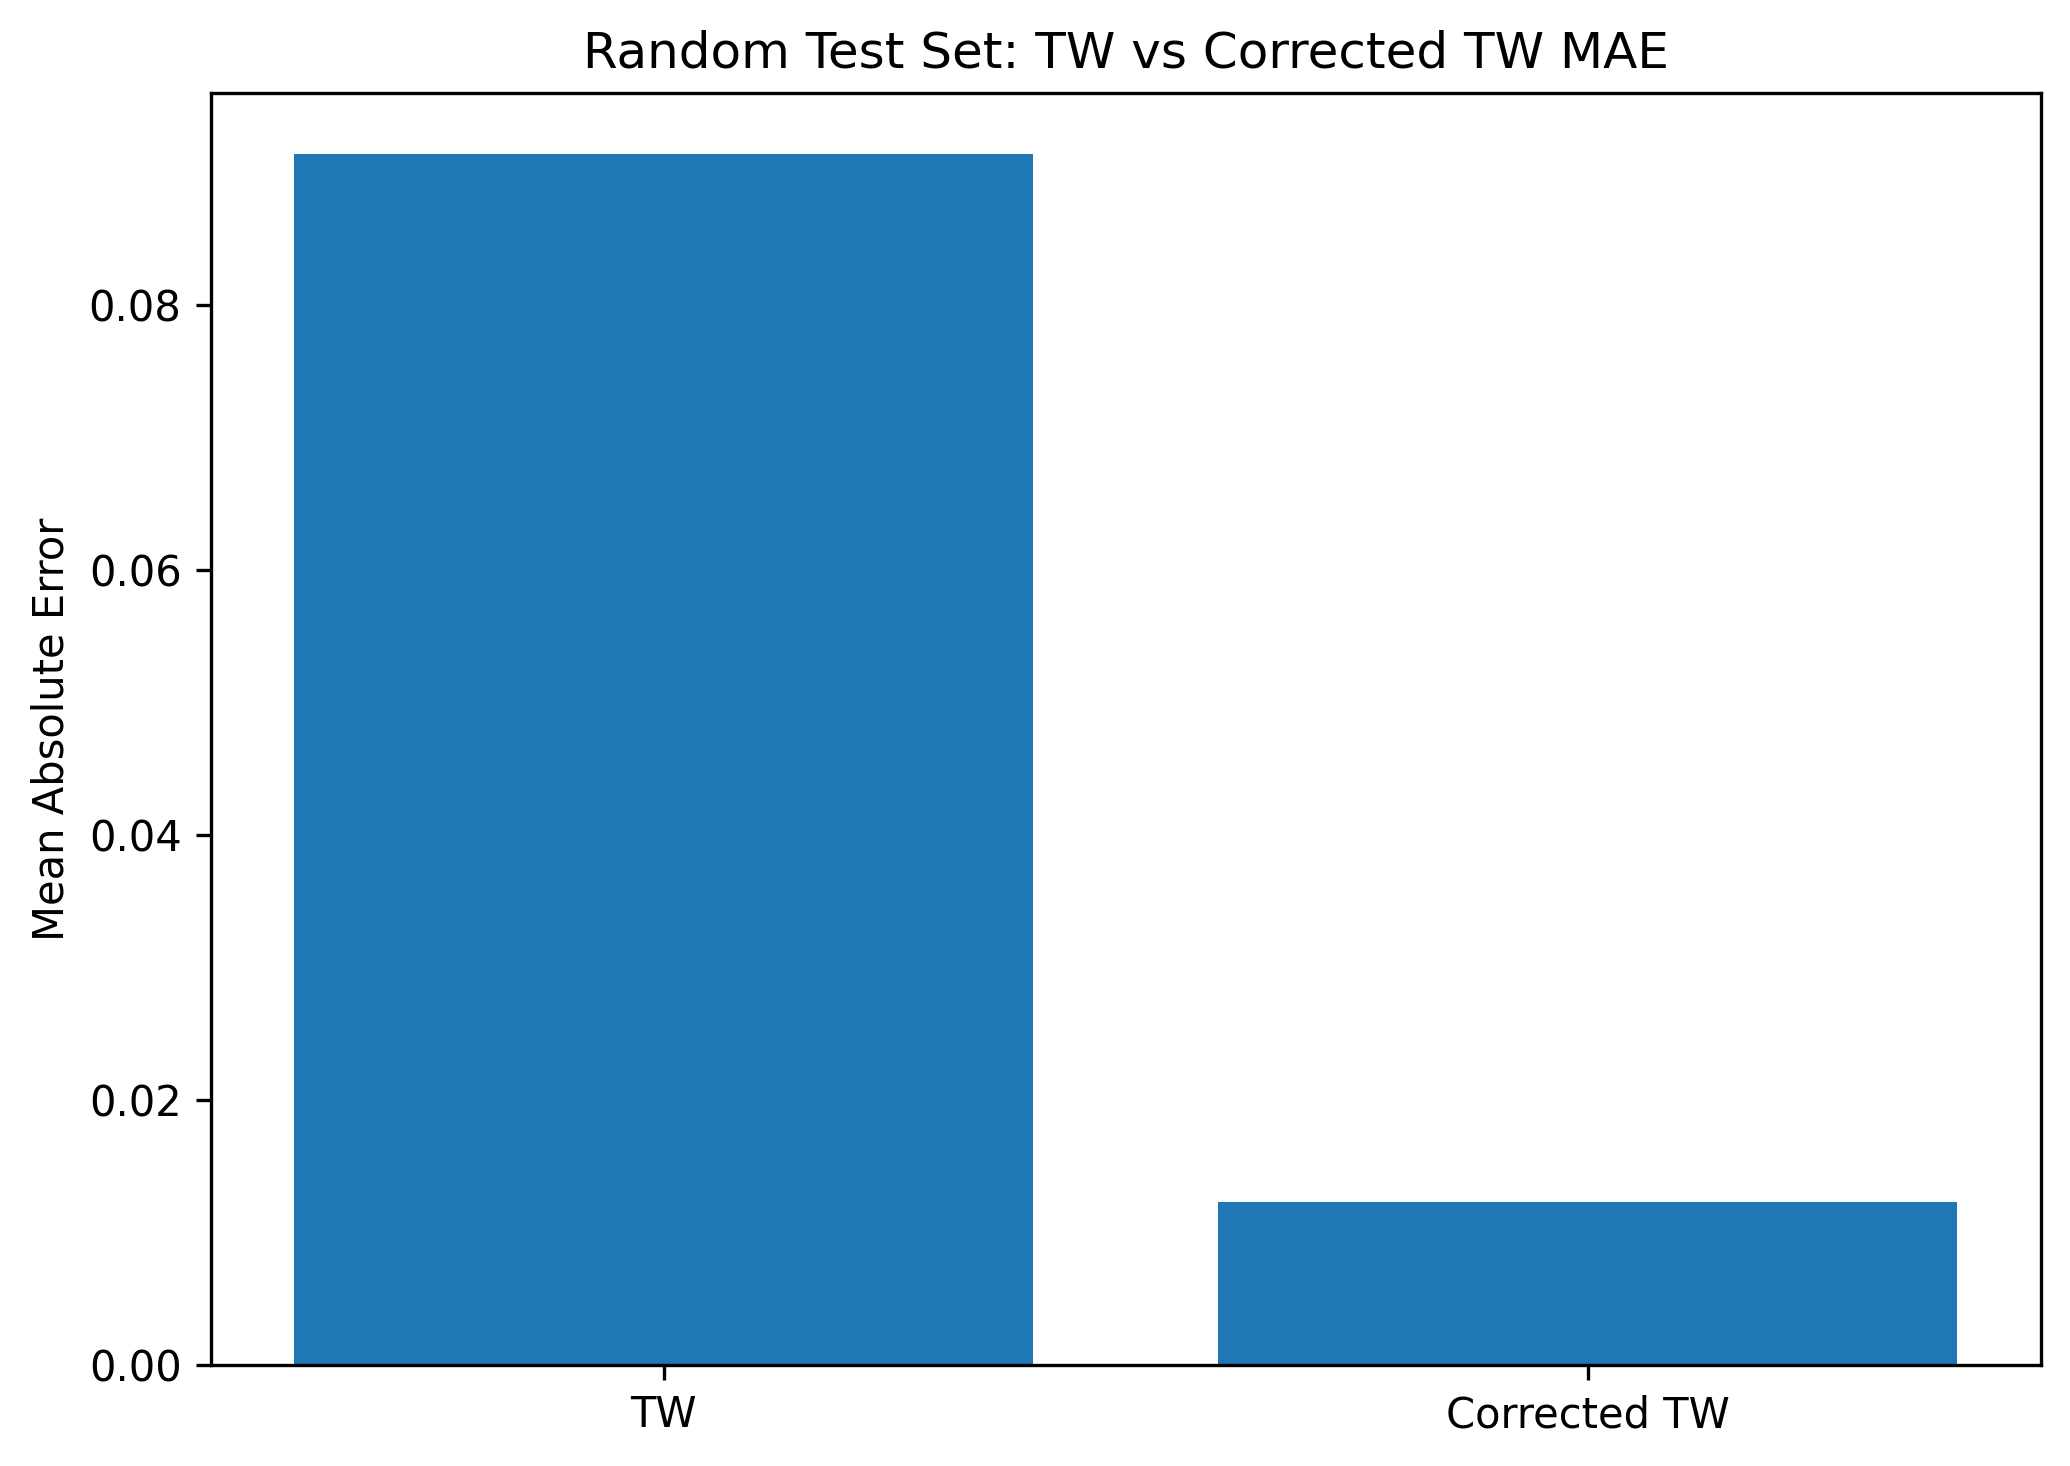


Robustness MAE Reduction Summary


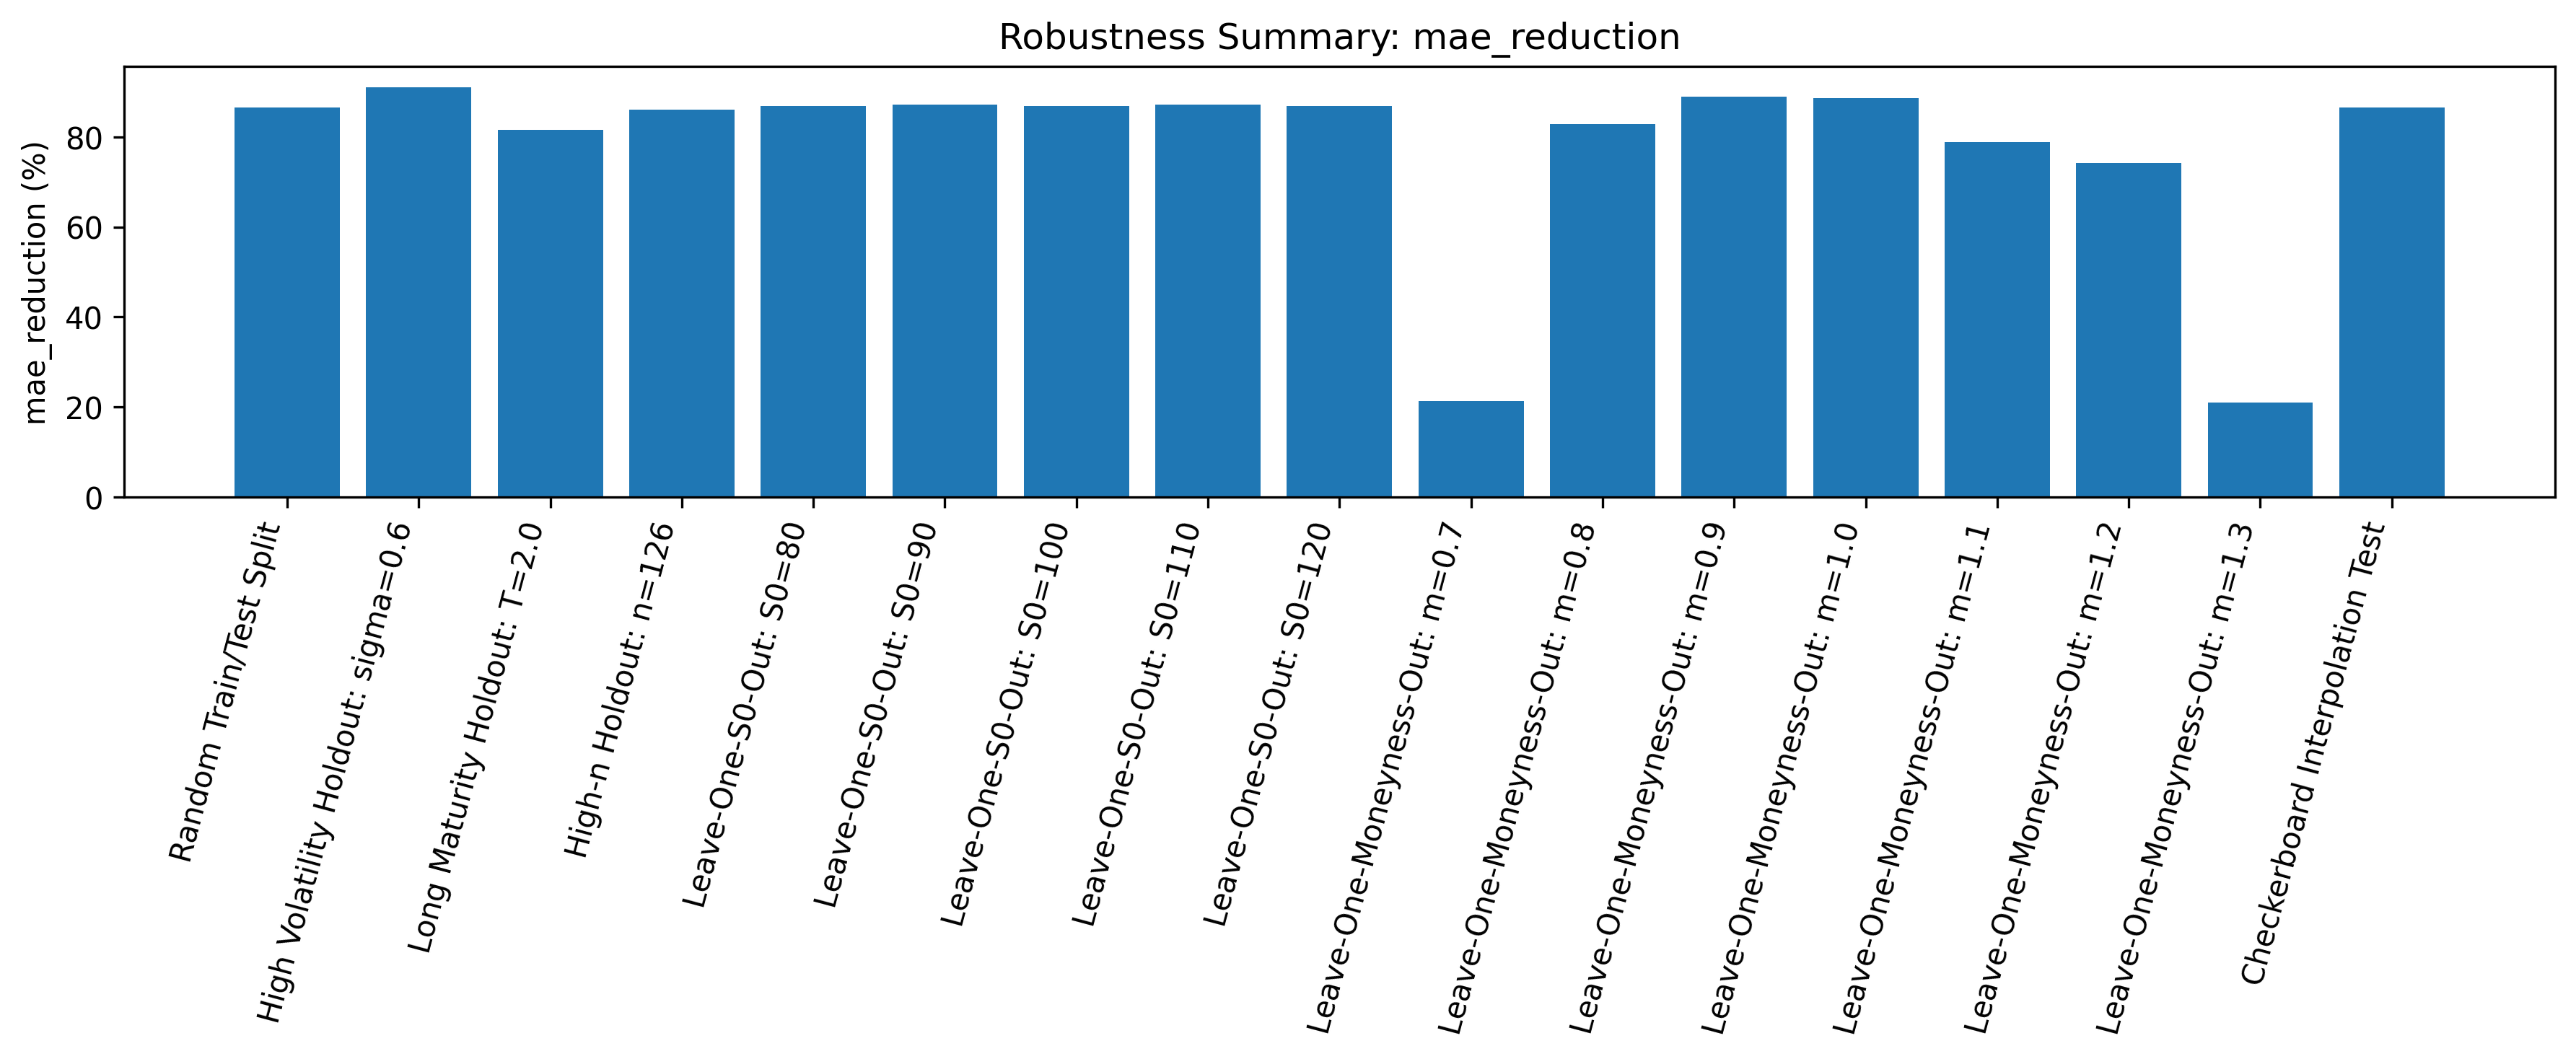

In [11]:
figure_files = [
    ("Approximation Error vs Strike", "error_vs_strike_sigma_0p2_n12.png"),
    ("Approximation Error vs Volatility", "error_vs_vol_K100_n12.png"),
    ("Runtime vs Monitoring Frequency", "runtime_vs_monitoring_frequency_K100_sigma_0p2.png"),
    ("Random Test Set: Original vs Corrected TW Error", "random_original_vs_corrected_tw_error.png"),
    ("Random Test Set: TW vs Corrected TW MAE", "random_tw_vs_corrected_mae.png"),
    ("Robustness MAE Reduction Summary", "robustness_mae_reduction_summary.png"),
]

for title, file_name in figure_files:
    path = FIGURE_DIR / file_name
    if path.exists():
        print(f"\n{title}")
        display(Image(filename=str(path), width=750))
    else:
        print(f"Missing figure: {path}")


## 11. Final Takeaway

This demo shows that the Turnbull-Wakeman approximation has a systematic residual structure relative to a control-variate Monte Carlo benchmark.

By learning the scaled residual with a cubic polynomial Ridge model, the corrected TW approximation keeps the speed of an analytical approximation while substantially improving pricing accuracy.
